Processing 2021...
  Using cached results for 2021
Processing 2022...
  Using cached results for 2022
Processing 2023...
  Using cached results for 2023
Processing 2024...
  Using cached results for 2024
Processing 2025...
  Using cached results for 2025
Computing averages...


/Users/Kathryn/Documents/Professional Development/Google Earth Engine/AppTrail_Phenology/fit_greendown_curves.py:337: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(np.stack(arrays, axis=0), axis=0).astype(np.float32)



Filtering pixel-years by CI width...
  2021: 440 pixels (all phases)  |  start: 454  middle: 797  end: 462
  2022: 409 pixels (all phases)  |  start: 526  middle: 1420  end: 534
  2023: 500 pixels (all phases)  |  start: 697  middle: 2193  end: 833
  2024: 423 pixels (all phases)  |  start: 780  middle: 1162  end: 562
  2025: 323 pixels (all phases)  |  start: 429  middle: 941  end: 474

Total pixel-years with all CI widths < 15 days: 2095
  By phase — start: 2886  middle: 6513  end: 2865

Building labeled feature table...
  2021: 440 qualifying pixels
  2022: 409 qualifying pixels
  2023: 500 qualifying pixels
  2024: 423 qualifying pixels
  2025: 323 qualifying pixels

Total labeled phenology observations: 78660
  Gap-filling 38867 NaN values in doy_minus_avg_middle (global avg middle DOY = 280.7)
        EVI      NDVI  evi_delta  evi_delta2  ndvi_delta  ndvi_delta2  \
2  1.026422  0.779424   0.894087   -0.180352    1.661120     0.129455   
3  0.918079  0.047946  -0.078541    0.7401

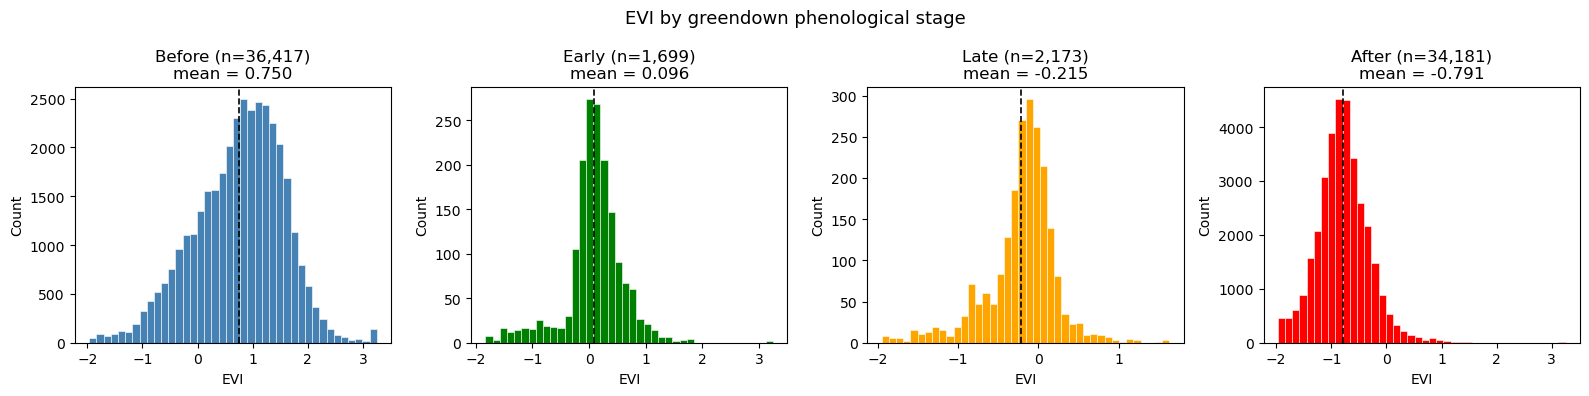

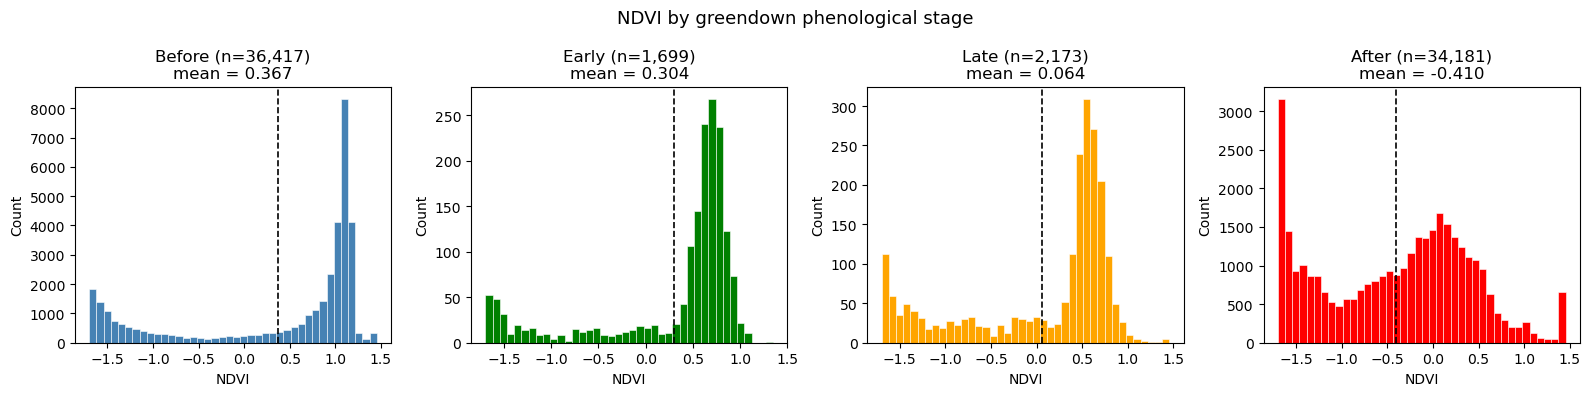

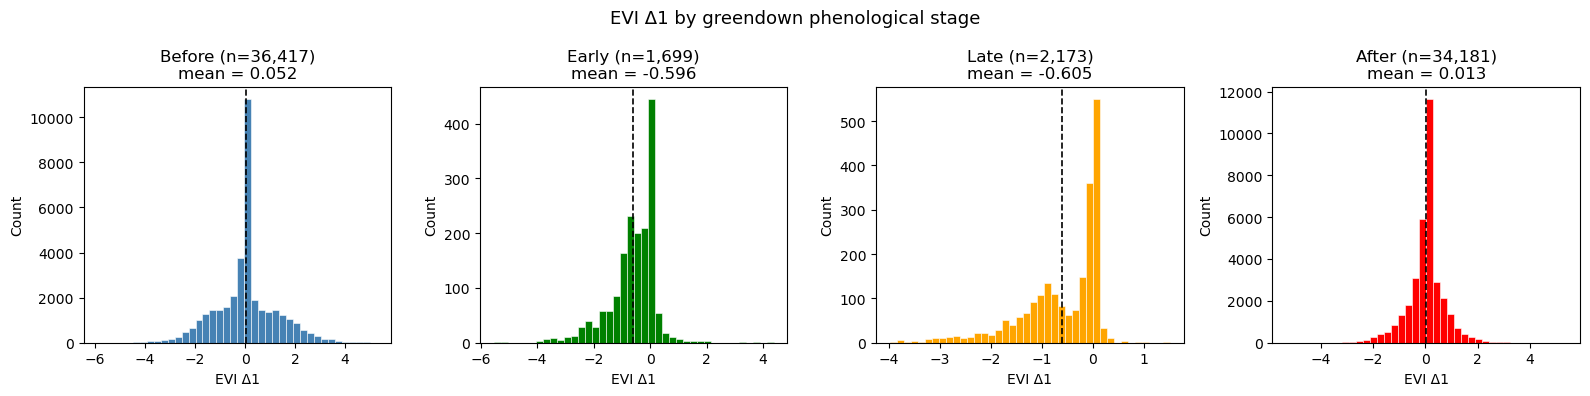

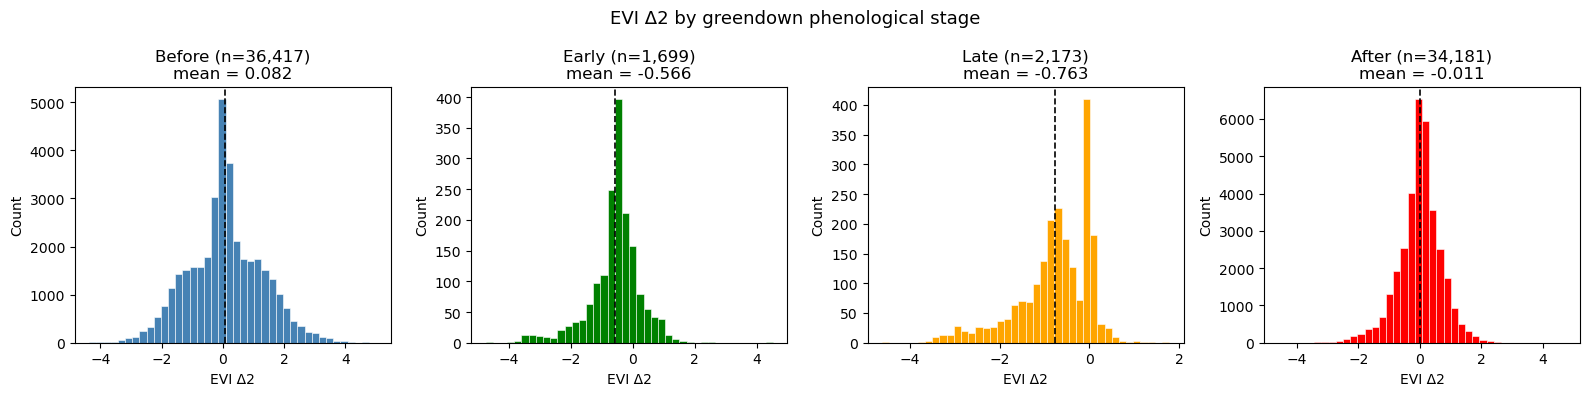

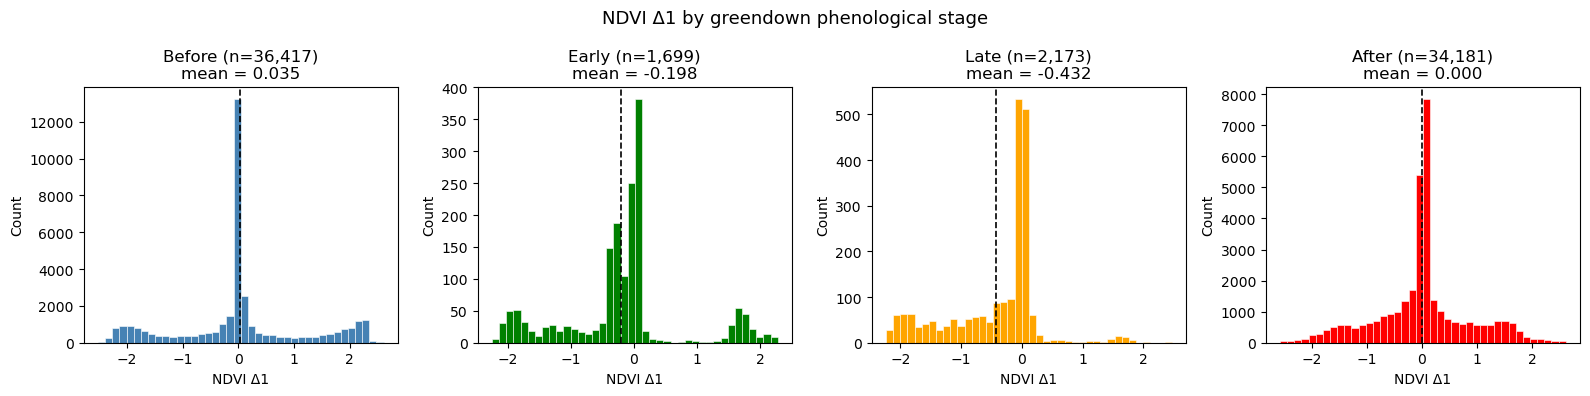

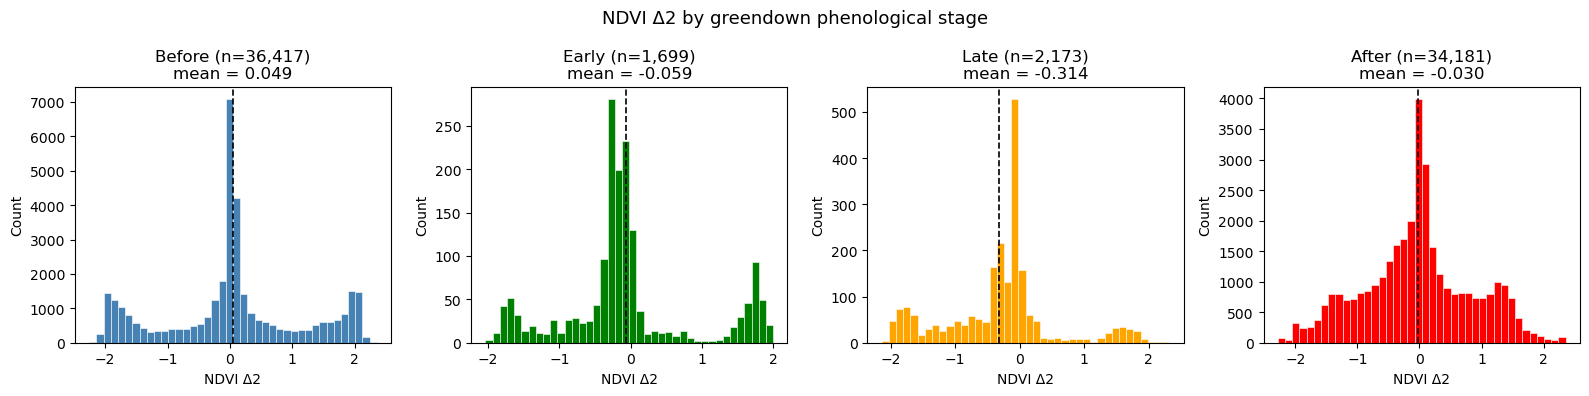

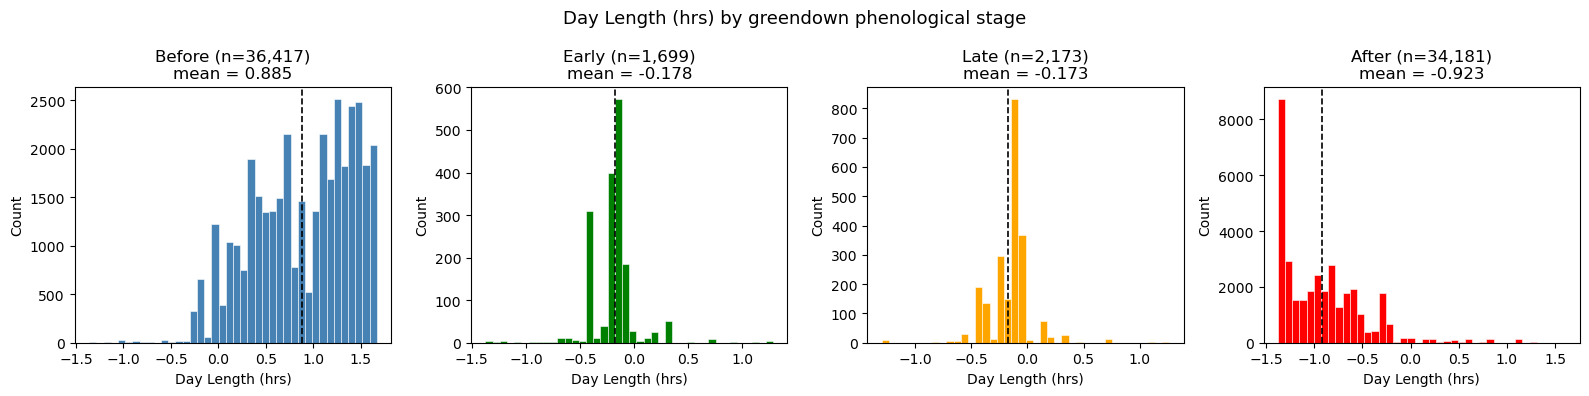

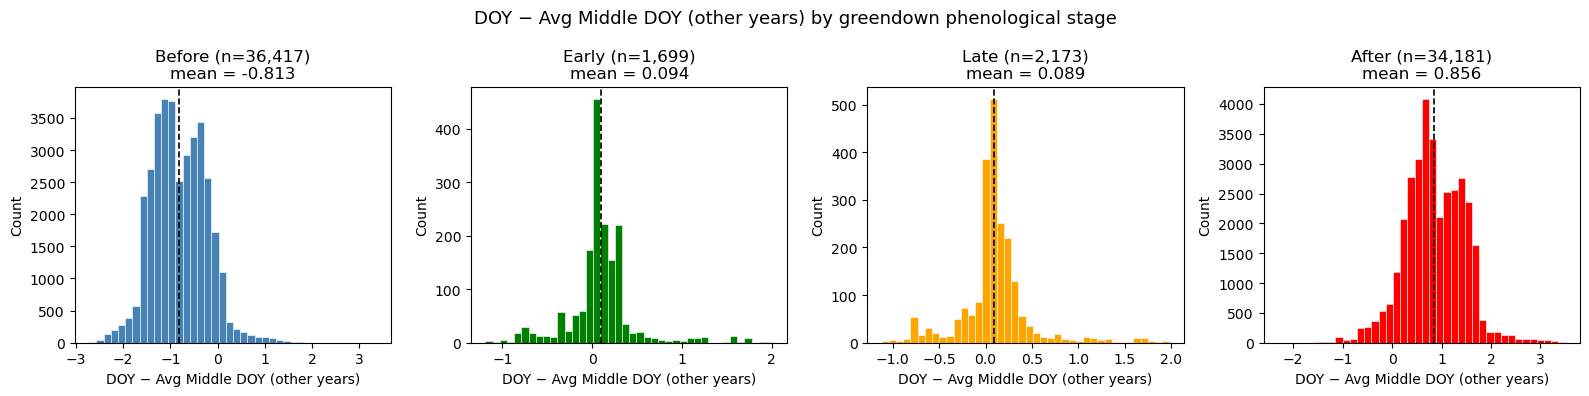

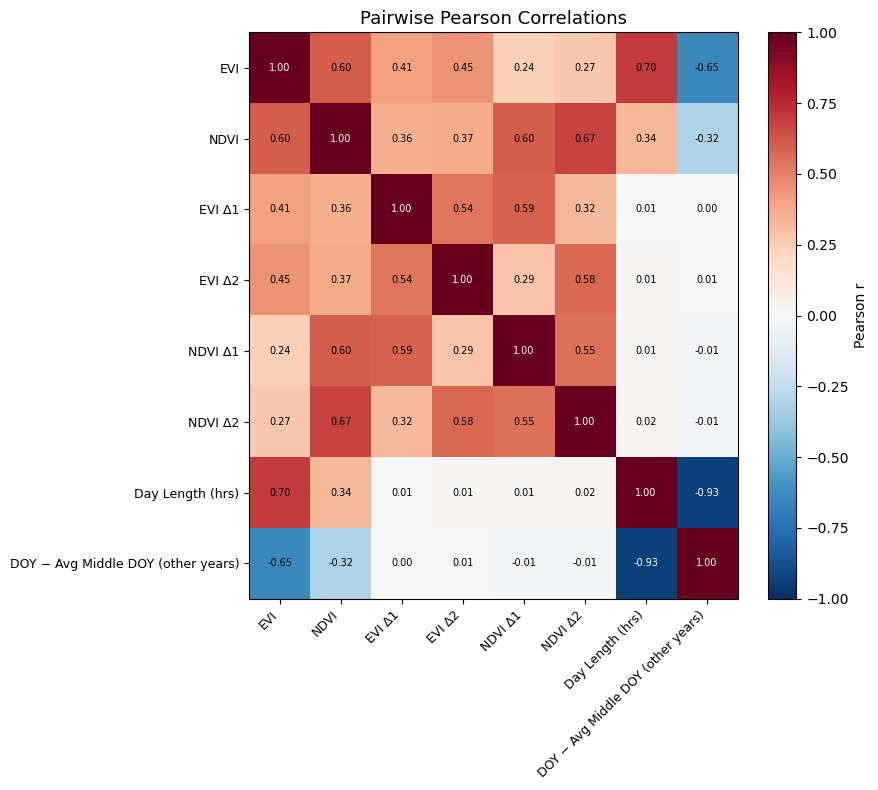

In [1]:
import datetime
import os
import ee
import geemap

from identify_locations import identify_forests, identify_route_buffer
from read_and_process_hls import compute_hls_indices
from fit_greendown_curves import compute_transition_dates, compute_average_transition_dates
from filter_ci_widths import count_narrow_ci_pixel_years
from build_data_table import build_feature_table
from edit_data_table import edit_feature_table
from plot_feature_distributions import plot_feature_distributions

ee.Initialize(project='turnkey-lacing-391919')

OUTPUT_DIR = './greendown_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

ma_forest    = identify_forests()
route_buffer = identify_route_buffer()

start_year    = 2021
previous_year = 2025

# ----------------------------
# Fit logistic curves for each year
# ----------------------------
all_year_paths = []
for y in range(start_year, previous_year + 1):
    print(f'Processing {y}...')
    hls   = compute_hls_indices(route_buffer, ma_forest, y)
    paths = compute_transition_dates(hls, route_buffer, ma_forest, y, output_dir=OUTPUT_DIR)
    all_year_paths.append(paths)

prev_year_paths = all_year_paths[-1]   # most recent year

# ----------------------------
# Average transition dates across all years
# ----------------------------
print('Computing averages...')
avg_paths = compute_average_transition_dates(all_year_paths, output_dir=OUTPUT_DIR)

# ----------------------------
# Filter: pixels with CI width < 15 days for all transitions
# ----------------------------
print('\nFiltering pixel-years by CI width...')
years = list(range(start_year, previous_year + 1))
count_narrow_ci_pixel_years(OUTPUT_DIR, years)

# ----------------------------
# Build labeled EVI/NDVI feature table and plot distributions
# ----------------------------
print('\nBuilding labeled feature table...')
feature_df = build_feature_table(OUTPUT_DIR, years)
#plot_feature_distributions(feature_df)
feature_df_edited = edit_feature_table(feature_df, OUTPUT_DIR)
print(feature_df_edited.head())
print('\nNaN counts per column:')
print(feature_df_edited.isna().sum())
plot_feature_distributions(feature_df_edited)

# ----------------------------
# Map all 6 layers
# ----------------------------
vis_kwargs = dict(colormap='rdylgn_r', vmin=250, vmax=320, nodata=-9999.0, opacity=0.9)

Map = geemap.Map()

# Most recent year
Map.add_raster(prev_year_paths['start'],  layer_name=f'{previous_year} Greendown Start',  **vis_kwargs)
Map.add_raster(prev_year_paths['middle'], layer_name=f'{previous_year} Greendown Middle', **vis_kwargs)
Map.add_raster(prev_year_paths['end'],    layer_name=f'{previous_year} Greendown End',    **vis_kwargs)

# Multi-year averages
Map.add_raster(avg_paths['start'],  layer_name=f'{start_year}–{previous_year} Avg Start',  **vis_kwargs)
Map.add_raster(avg_paths['middle'], layer_name=f'{start_year}–{previous_year} Avg Middle', **vis_kwargs)
Map.add_raster(avg_paths['end'],    layer_name=f'{start_year}–{previous_year} Avg End',    **vis_kwargs)

Map.add_colorbar(
    {'min': 250, 'max': 320, 'palette': ['darkgreen', 'yellow', 'orange', 'red']},
    label='Greendown Transition DOY  (250 ≈ Sep 7  →  320 ≈ Nov 16)',
    orientation='horizontal'
)

#Map